In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
from PIL import Image
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import numpy as np

In [13]:
import tarfile
import os

dataset_file = "edges2shoes.tar.gz"



In [5]:
class Edges2ShoesDataset(Dataset):
    def __init__(self, root):
        self.root = root
        self.images = os.listdir(root)
        self.transform = transforms.Compose([
            transforms.Resize((256, 512)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.images[idx]))
        img = self.transform(img)

        edge = img[:, :, :256]
        real = img[:, :, 256:]
        return edge, real

In [33]:
from torch.utils.data import Subset

train_data = Edges2ShoesDataset("edges2shoes/train")

# Take only first 200 images for fast training
small_train = Subset(train_data, range(500))

train_loader = DataLoader(small_train, batch_size=4, shuffle=True)

In [34]:
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        def down(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 4, 2, 1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        def up(in_c, out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c, out_c, 4, 2, 1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        self.d1 = down(3, 64)
        self.d2 = down(64, 128)
        self.d3 = down(128, 256)

        self.u1 = up(256, 128)
        self.u2 = up(256, 64)
        self.u3 = nn.ConvTranspose2d(128, 3, 4, 2, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)

        u1 = self.u1(d3)
        u2 = self.u2(torch.cat([u1, d2], 1))
        out = self.u3(torch.cat([u2, d1], 1))
        return self.tanh(out)

In [35]:
class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 1, 4, 1, 1)
        )

    def forward(self, x, y):
        return self.model(torch.cat([x, y], 1))

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

adv_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

In [38]:
G_losses = []
D_losses = []
epochs = 30

for epoch in range(epochs):
    for i, (edge, real) in enumerate(train_loader):

        edge, real = edge.to(device), real.to(device)

        # ---- Train Discriminator ----
        fake = G(edge)

        real_pred = D(edge, real)
        fake_pred = D(edge, fake.detach())

        real_loss = adv_loss(real_pred, torch.ones_like(real_pred))
        fake_loss = adv_loss(fake_pred, torch.zeros_like(fake_pred))
        d_loss = (real_loss + fake_loss) / 2

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # ---- Train Generator ----
        fake_pred = D(edge, fake)
        g_adv = adv_loss(fake_pred, torch.ones_like(fake_pred))
        g_l1 = l1_loss(fake, real)
        g_loss = g_adv + 100 * g_l1

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()


        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())

        if i % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Step [{i}/{len(train_loader)}] "
                  f"D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

Epoch [1/30] Step [0/125] D Loss: 0.3486, G Loss: 15.1042
Epoch [1/30] Step [20/125] D Loss: 0.2613, G Loss: 17.9851
Epoch [1/30] Step [40/125] D Loss: 0.2932, G Loss: 15.7155
Epoch [1/30] Step [60/125] D Loss: 0.2765, G Loss: 11.7014
Epoch [1/30] Step [80/125] D Loss: 0.2639, G Loss: 18.0079
Epoch [1/30] Step [100/125] D Loss: 0.3067, G Loss: 18.4246
Epoch [1/30] Step [120/125] D Loss: 0.2988, G Loss: 14.0719
Epoch [2/30] Step [0/125] D Loss: 0.2352, G Loss: 16.3376
Epoch [2/30] Step [20/125] D Loss: 0.2805, G Loss: 19.1328
Epoch [2/30] Step [40/125] D Loss: 0.4281, G Loss: 12.5035
Epoch [2/30] Step [60/125] D Loss: 0.1550, G Loss: 15.9359
Epoch [2/30] Step [80/125] D Loss: 0.1553, G Loss: 17.4842
Epoch [2/30] Step [100/125] D Loss: 0.2454, G Loss: 14.6415
Epoch [2/30] Step [120/125] D Loss: 0.1981, G Loss: 18.5726
Epoch [3/30] Step [0/125] D Loss: 0.4506, G Loss: 15.9478
Epoch [3/30] Step [20/125] D Loss: 0.3043, G Loss: 15.7156
Epoch [3/30] Step [40/125] D Loss: 0.2851, G Loss: 15.2

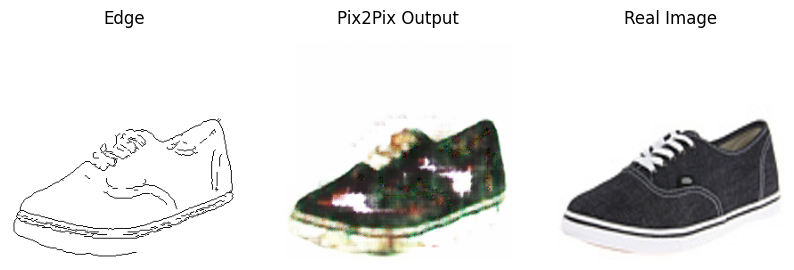

In [39]:
edge, real = next(iter(train_loader))
edge = edge.to(device)

fake = G(edge).cpu().detach()

plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.title("Edge")
plt.imshow(edge[0].permute(1,2,0).cpu())
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Pix2Pix Output")
plt.imshow(fake[0].permute(1,2,0))
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Real Image")
plt.imshow(real[0].permute(1,2,0))
plt.axis("off")

plt.show()

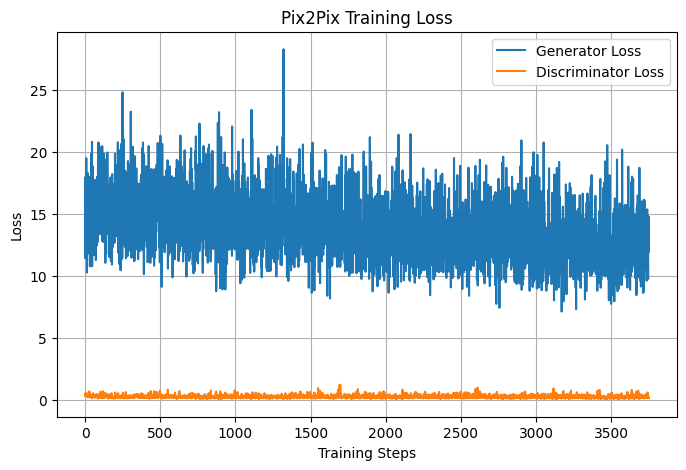

In [40]:
plt.figure(figsize=(8,5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Pix2Pix Training Loss")
plt.legend()
plt.grid()
plt.show()

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')